# Homework 1 – Clustering & Disease Phenotyping
**Dataset**: Tabula Muris Senis (single-cell RNA-seq across mouse organs, young & aged)

**Goal**: Identify tissue-specific phenotypes and cell-type clusters to understand single-cell transcriptomes.

## Questions
### Conceptual (answer in PDF)  (20 pts)
1. (3 points) Define a clinical phenotype. Why is unsupervised clustering useful for discovering disease subtypes?
2. (3 points) Compare k-means vs hierarchical clustering. What assumptions do they make about cluster shape/structure?
3. (4 points) How can dimensionality reduction (PCA) help in analyzing high-dimensional scRNA-seq data?
4. (5 points) In disease phenotyping using cluster analysis, why is it important to identify  clinically recognizable clusters? Put differently: what is/are the problems if the identified  clusters are not clinically meaningful?
5. (5 points) Partitioning Around Medoids (PAM) with Gower’s distance is designed for  clustering mixed data types. Why did K-means with Euclidean distance perform better on the clinical data (with mixed data types) in Lecture 5? Similarly, why did K-means with Euclidean distance outperform K-means with Manhattan distance on the same dataset?


### Coding & Analysis (80 pts)
Complete the TODO sections below and answer the Interpretation (written) questions in the PDF.

## 0. Setup & Data Loading
Load Tabula Muris Senis dataset and select 3 tissues (Limb_Muscle, Pancreas, Spleen) with ~5000 cells total.

In [ ]:
#if running in co-lab this chunk will download necessary packages
!pip install scanpy
!pip install scikit-misc
!pip install igraph leidenalg

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy import stats
from pathlib import Path
from statsmodels.stats.multitest import multipletests


# Create output directories
import os
os.makedirs('figs', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

In [3]:
# Load pre-subset AnnData object (~5000 cells, 3 tissues: Limb_Muscle, Pancreas, Spleen)

adata = sc.read_h5ad("HW1_2026_subset.h5ad")

# Print basic info
print(adata)
print("Tissues included:", adata.obs["tissue"].unique().tolist())
print("Number of cells:", adata.n_obs)
print("Number of genes:", adata.n_vars)

AnnData object with n_obs × n_vars = 5000 × 20138
    obs: 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'n_genes', 'sex', 'subtissue', 'tissue', 'tissue_free_annotation', 'tissue_selected'
    var: 'n_cells'
    uns: 'hw1_triplet_info'
    layers: 'counts', None (.X)
Tissues included: ['Spleen', 'Limb_Muscle', 'Pancreas']
Number of cells: 5000
Number of genes: 20138


## 1. Data Preprocessing (5 pts)
Filter, normalize, and log-transform.

In [5]:
# 1. Filter cells and genes
# (we give them the function calls, but they must fill in thresholds)
sc.pp.filter_cells(adata, min_genes=200)      # TODO: confirm threshold (e.g., 200)
sc.pp.filter_genes(adata, min_cells=3)     # TODO: confirm threshold (e.g., 3)

# 2. Normalize to 10,000 reads per cell
sc.pp.normalize_total(adata, target_sum=10000)  # TODO: confirm target sum from the comment above

# 3. Log-transform (natural log, add 1 inside log)
sc.pp.log1p(adata)

# Highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3")
adata_hvg = adata[:, adata.var["highly_variable"]].copy()

# Scale features
sc.pp.scale(adata_hvg, max_value=10)

print("Preprocessing complete.")
print(adata)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23708\3531476413.py:13: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3")


Preprocessing complete.
AnnData object with n_obs × n_vars = 5000 × 16557
    obs: 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'n_genes', 'sex', 'subtissue', 'tissue', 'tissue_free_annotation', 'tissue_selected'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hw1_triplet_info', 'log1p', 'hvg'
    layers: 'counts', None (.X)


C:\Python313\Lib\functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


## 2. Dimensionality Reduction (20 pts)
Apply PCA and visualize tissue separation. You may use any library of your choice (e.g., scanpy, pandas + sklearn).

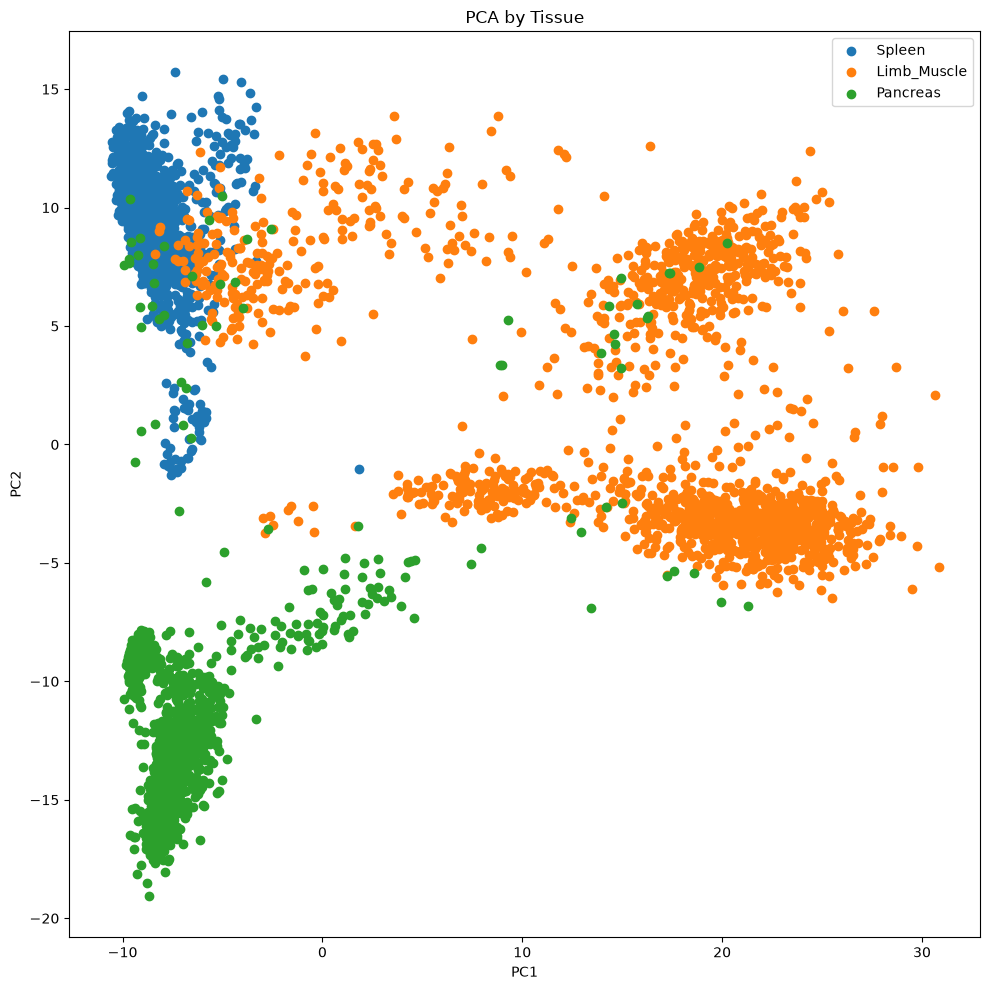

In [9]:
# TODO:
# 3. Apply PCA (50 components)
# 4. Plot first 2 PCs colored by tissue
N_PCs = 50 # Number of PCA components
# YOUR CODE HERE

sc.tl.pca(adata_hvg, n_comps=N_PCs)
X_pca = adata_hvg.obsm["X_pca"]

# Plot PC1 vs PC2
tissues = adata_hvg.obs["tissue"]
plt.figure(figsize=(10, 10))
for tissue in tissues.unique():
    mask = tissues == tissue
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=tissue
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA by Tissue")
plt.legend()
plt.tight_layout()
plt.savefig("figs/pca_by_tissue.png")
plt.show()


# Save plot (WILL BE GRADED)
# save figure to ('figs/pca_by_tissue.png')


#### Interpretation (written) question:

*Answer in PDF:*

Do the tissues separate in PCA space? Explain your observation.


## 3. K-means Clustering (20 pts)
Determine optimal K and compare clusters to tissue labels.

best_k: 6
KMeans  k=6 Sil=0.397 ARI=0.604 NMI=0.665
Tissue   Limb_Muscle  Pancreas  Spleen
Cluster                               
0                977        11       0
1                167        22    1573
2                  0       917       0
3                  0       678       0
4                 97         8     113
5                421        16       0


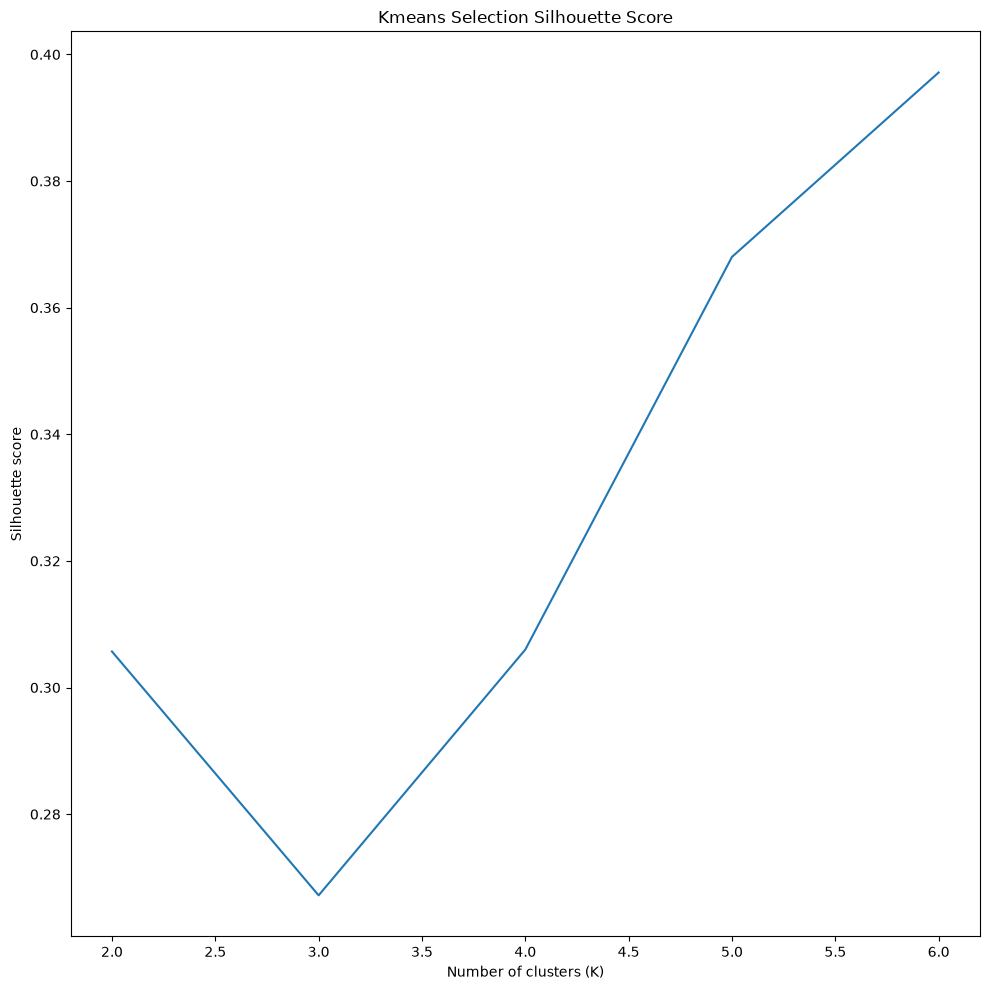

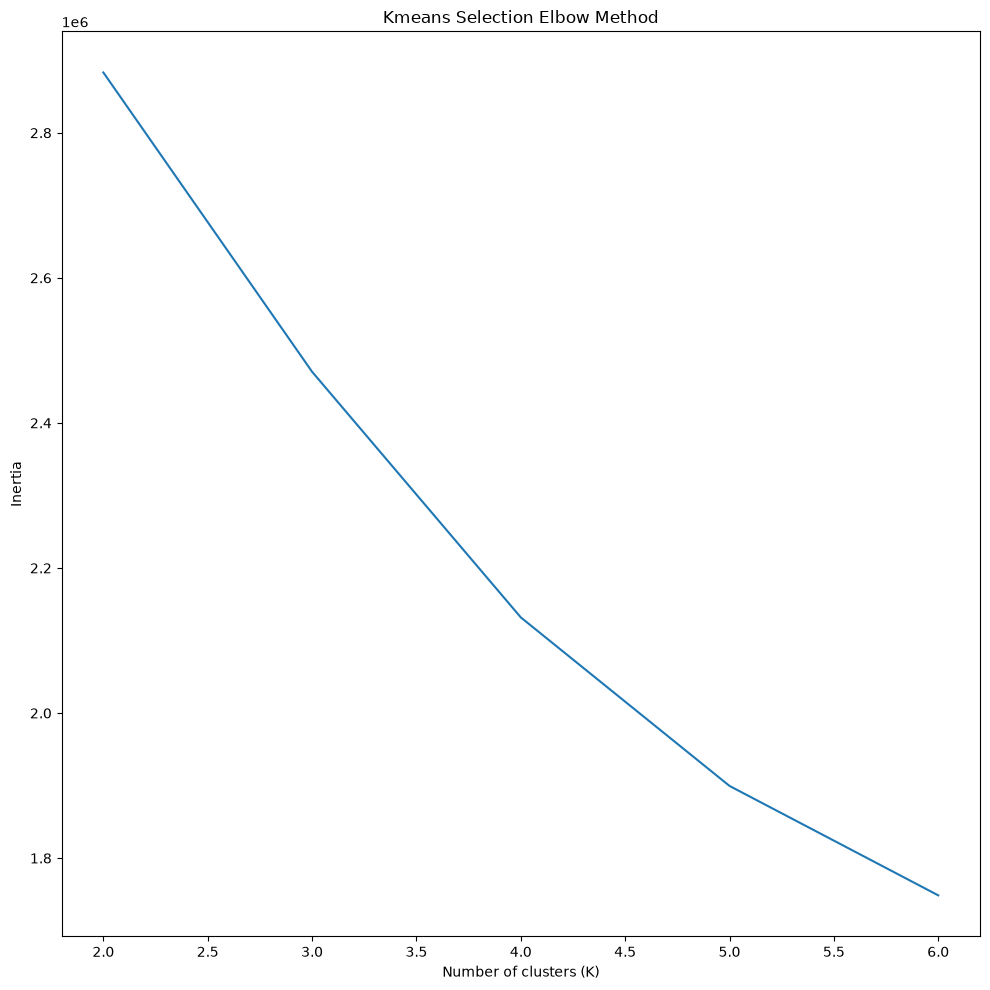

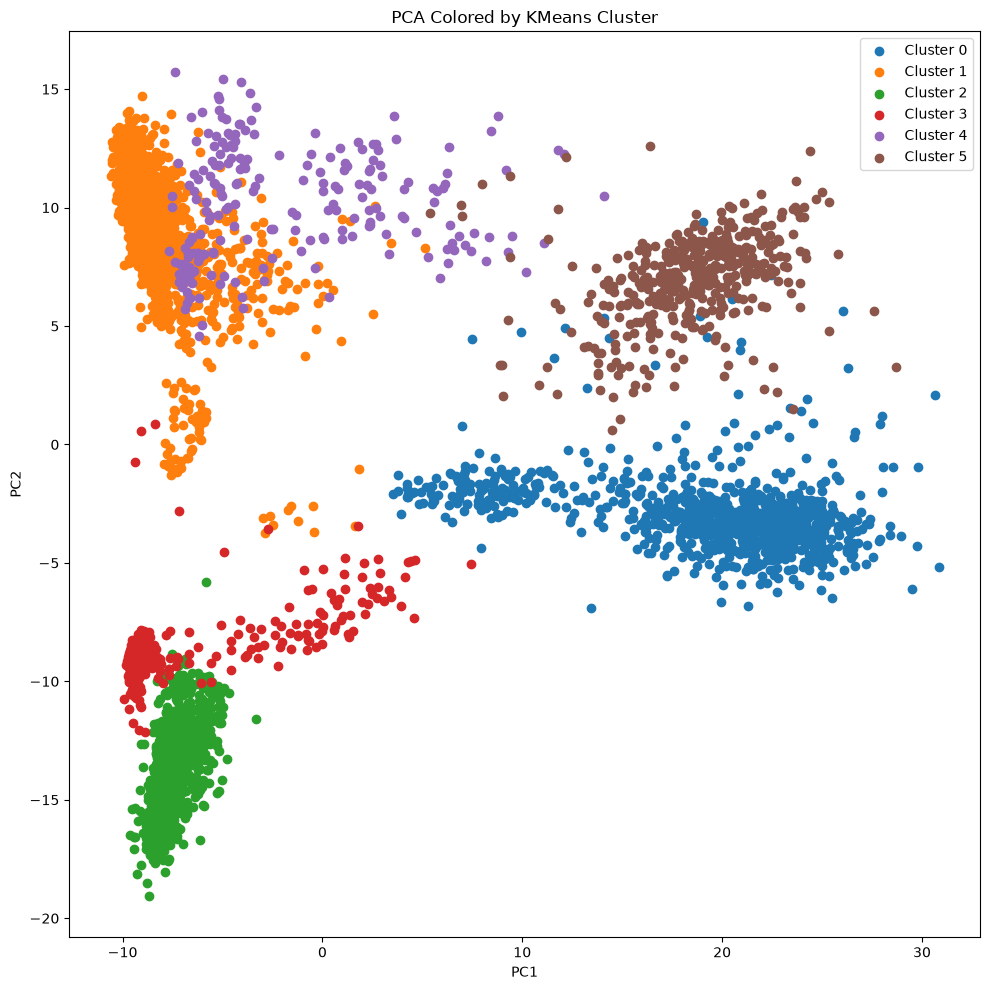

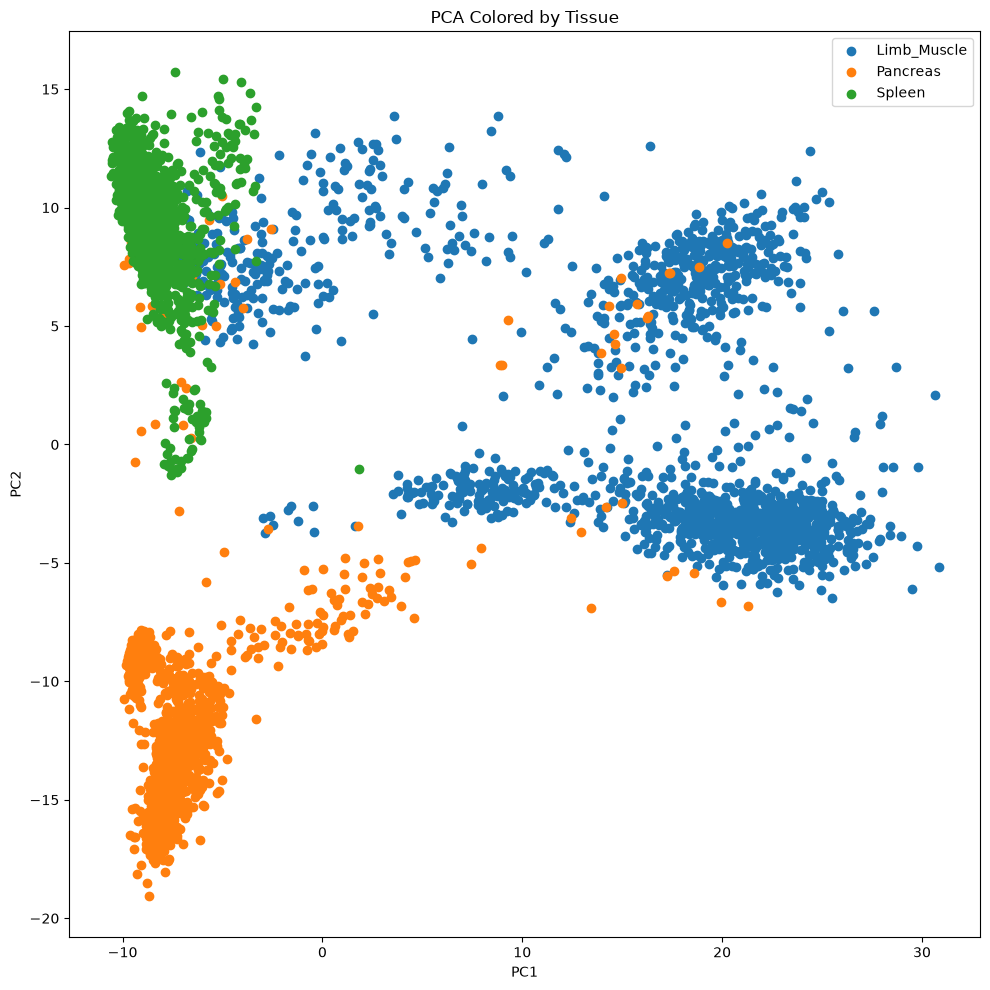

In [23]:
# TODO:
# import the tools you will use
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

N_PCS   = 50
K_RANGE = [2, 3, 4, 5, 6]
SEED    = 42
LABEL_COL = "tissue"

# TODO: ensure you are using exactly the first N_PCS PCs
pca_data = adata_hvg.obsm["X_pca"][:, :N_PCS]
tissue_labels = adata_hvg.obs[LABEL_COL].values

# TODO: compute elbow (inertia) and silhouette over K_RANGE (use random_state=SEED, n_init=50)
inertias = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=50)
    labels = km.fit_predict(pca_data)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(pca_data, labels))

# TODO: choose best_k by max silhouette; if tie, pick the smaller k
best_k = K_RANGE[np.argmax(silhouettes)]
print("best_k:", best_k)

# TODO: fit final KMeans with best_k (use random_state=SEED, n_init=50)
kmeans_final = KMeans(n_clusters=best_k, random_state=SEED, n_init=50)
kmeans_labels = kmeans_final.fit_predict(pca_data)

# TODO: compute metrics (silhouette, ARI, NMI) using (X_pca_use, km_labels, y_true)
# km_sil = ...
# km_ari = ...
# km_nmi = ...
# print(f"KMeans  k={best_k}  Sil={km_sil:.3f}  ARI={km_ari:.3f}  NMI={km_nmi:.3f}")
km_sil = silhouette_score(pca_data,kmeans_labels) #silhouette
km_ari = adjusted_rand_score(tissue_labels, kmeans_labels) #ARI
km_nmi = normalized_mutual_info_score(tissue_labels, kmeans_labels) #NMI

print(f"KMeans  k={best_k}", f"Sil={km_sil:.3f}", f"ARI={km_ari:.3f}", f"NMI={km_nmi:.3f}")

# TODO: print or draw confusion table clusters × tissue
# optionally save to -> outputs/kmeans_confusion.csv
confusion = pd.crosstab(kmeans_labels, tissue_labels, rownames=["Cluster"], colnames=["Tissue"])
print(confusion)
confusion.to_csv("outputs/kmeans_confusion.csv")


# TODO: plot and save k-selection curves (Elbow + Silhouette)
# save figure in -> figs/kmeans_kselection_silhouette.png
# save figure in -> figs/kmeans_kselection_elbow.png
plt.figure(figsize=(10, 10))
plt.plot(K_RANGE, silhouettes)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score")
plt.title("Kmeans Selection Silhouette Score")
plt.tight_layout()
plt.savefig("figs/kmeans_kselection_silhouette.png")
plt.show()


plt.figure(figsize=(10, 10))
plt.plot(K_RANGE,inertias)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Kmeans Selection Elbow Method")
plt.tight_layout()
plt.savefig("figs/kmeans_kselection_elbow.png")
plt.show()

# TODO: PCA scatter (PC1 vs PC2) colored by KMeans clusters →
# save figure in -> figs/pca_kmeans.png
plt.figure(figsize=(10, 10))
for cluster in np.unique(kmeans_labels):
    mask = kmeans_labels == cluster
    plt.scatter(pca_data[mask, 0], pca_data[mask, 1], label=f"Cluster {cluster}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Colored by KMeans Cluster")
plt.legend()
plt.tight_layout()
plt.savefig("figs/pca_kmeans.png")
plt.show()

# TODO: PCA scatter (PC1 vs PC2) colored by tissue
# save figure in -> figs/pca_tissue.png
plt.figure(figsize=(10, 10))
for tissue in np.unique(tissue_labels):
    mask = tissue_labels == tissue
    plt.scatter(pca_data[mask, 0], pca_data[mask, 1], label=tissue)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Colored by Tissue")
plt.legend()
plt.tight_layout()
plt.savefig("figs/pca_tissues.png")
plt.show()

#### Interpretation (written) question:

*Answer in PDF:*

How well do clusters align with tissue labels?

## 4. Alternative Clustering Method (20 pts)
Apply graph-based or hierarchical Clustering

K-means Silhouette Score: 0.3972
Hierarchical Silhouette Score: 0.3967


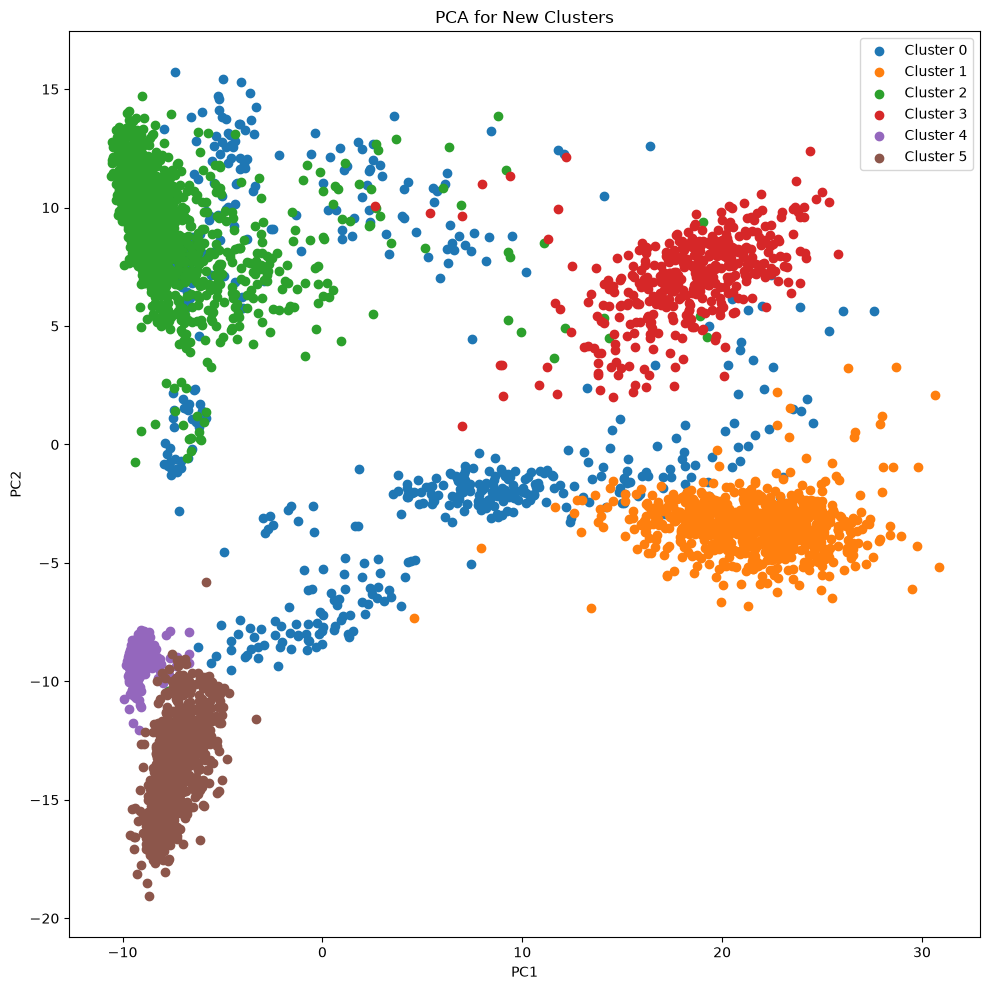

In [31]:
# Use Hierarchical or Graph-based (Leiden/Louvain) clustering as alternative clustering method

# TODO: Perform Louvain or Agglomerative (hierarchical) clustering on PCA-reduced data

# choose Hierarchical clustering
from sklearn.cluster import AgglomerativeClustering
hierarchical_model = AgglomerativeClustering(n_clusters=best_k, linkage="ward") 
# Use the same number of clusters as K-means for a fair comparison.
# ward minimizes within-cluster variance. Better fit for this case.
hierarchical_labels = hierarchical_model.fit_predict(pca_data)

# TODO: Save the resulting cluster labels
adata_hvg.obs["hierarchical_cluster"] = hierarchical_labels

# TODO: Calculate silhouette score for k-means clusters (already computed earlier)
kmeans_silhouette = silhouette_score(pca_data, kmeans_labels)

# TODO: Calculate silhouette score for your new clusters
hierarchical_silhouette = silhouette_score(pca_data, hierarchical_labels)

# TODO: Print or display all silhouette scores for comparison (including k-means)
print(f"K-means Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Hierarchical Silhouette Score: {hierarchical_silhouette:.4f}")

# TODO: Plot results (PCA) for new clusters (PC1 vs PC2)
plt.figure(figsize=(10, 10))
for cluster in np.unique(hierarchical_labels):
    mask = hierarchical_labels == cluster
    plt.scatter(pca_data[mask, 0], pca_data[mask, 1], label=f"Cluster {cluster}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA for New Clusters")
plt.legend()
plt.tight_layout()
plt.savefig("figs/pca_for_new_clusters.png")
plt.show()

#### Interpretation (written) question:

*Answer in PDF:*

How does your alternative clustering method compare to k-means clustering?

## 5. Marker Gene Identification (15 pts)
Find top 5 marker genes for one cluster using differential expression. In this part you just make the following code work with your data. You may variable names and structure while maintaining functionality.

In [35]:
# Marker gene identification for each cluster

# Expression matrix: cells × genes (from preprocessed HVG data)
expression_matrix = adata_hvg.to_df()

# Choose cluster assignments (KMeans, Leiden, or Hierarchical)
cluster_assignments = kmeans_labels   # <-- TODO: change here if analyzing Leiden/Hierarchical
# choose kmeans method
y_true = adata_hvg.obs["tissue"].values

all_markers = {}

for clust in np.unique(cluster_assignments):
    # TODO: make a boolean mask for cells in this cluster
    mask = cluster_assignments == clust # select cluster #clust cells

    # TODO: find the majority tissue among cells in this cluster
    majority_tissue = pd.Series(y_true[mask]).mode()[0]

    # TODO: loop over all genes and compute Welch’s t-test (target vs other cells)
    scores, pvals = [], []
    for g in range(expression_matrix.shape[1]):
        expr_target = expression_matrix.iloc[mask, g]
        expr_other = expression_matrix.iloc[~mask, g]
        t_stat, p_val = stats.ttest_ind(expr_target, expr_other, equal_var=False)
        scores.append(t_stat)
        pvals.append(p_val)

    # Multiple testing correction (already provided)
    _, pvals_adj, _, _ = multipletests(pvals, method="fdr_bh")

    # Collect results for this cluster
    markers = pd.DataFrame({
        "gene": expression_matrix.columns,
        "t_stat": scores,
        "pval": pvals,
        "pval_adj": pvals_adj,
        # TODO: compute log fold change (mean target − mean other)
        "logFC": (expression_matrix.loc[mask].mean(axis=0).values - expression_matrix.loc[~mask].mean(axis=0).values)
    })

    # TODO: filter markers by adjusted p-value < 0.05
    # HINT: use markers[markers["pval_adj"] < 0.05]
    significant_markers = markers[markers["pval_adj"] < 0.05].copy()
    
    # TODO: then rank by absolute logFC and select top 5
    significant_markers["abs_logFC"] = significant_markers["logFC"].abs()

    top5 = (significant_markers.sort_values("abs_logFC", ascending=False).head(5).drop(columns="abs_logFC"))

    # Add tissue label column for clarity
    top5.insert(0, "majority_tissue", majority_tissue)

    all_markers[clust] = top5
    print(f"\nTop 5 marker genes for cluster {clust} (majority tissue = {majority_tissue})")
    print(top5)

    # Save results per cluster
    top5.to_csv(f"outputs/top5_markers_cluster{clust}.csv", index=False)

print("\nMarker gene identification complete. Results saved in outputs/ folder.")


C:\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)



Top 5 marker genes for cluster 0 (majority tissue = Limb_Muscle)
    majority_tissue      gene     t_stat           pval       pval_adj  \
214     Limb_Muscle       Dcn  72.493668   0.000000e+00   0.000000e+00   
948     Limb_Muscle       Gsn  84.065749   0.000000e+00   0.000000e+00   
966     Limb_Muscle  Serping1  68.360745   0.000000e+00   0.000000e+00   
657     Limb_Muscle    Igfbp6  56.693771   0.000000e+00   0.000000e+00   
310     Limb_Muscle  Serpinf1  54.723096  8.644512e-304  4.433083e-302   

        logFC  
214  2.199515  
948  2.178059  
966  2.146704  
657  2.087279  
310  2.070849  


C:\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)



Top 5 marker genes for cluster 1 (majority tissue = Spleen)
     majority_tissue     gene      t_stat  pval  pval_adj     logFC
1245          Spleen     Cd52  117.889035   0.0       0.0  1.812479
858           Spleen  Ptprcap   90.141075   0.0       0.0  1.802911
627           Spleen     Rac2  103.825547   0.0       0.0  1.794118
1690          Spleen   Coro1a  104.727600   0.0       0.0  1.777347
1623          Spleen     Cd37   73.340019   0.0       0.0  1.684066


C:\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


...


Top 5 marker genes for cluster 3 (majority tissue = Pancreas)
     majority_tissue      gene      t_stat  pval  pval_adj     logFC
1456        Pancreas      Reg1  131.728634   0.0       0.0  2.795051
921         Pancreas  Pnliprp1  138.618452   0.0       0.0  2.792646
1404        Pancreas      Cpa2  122.992864   0.0       0.0  2.789077
1352        Pancreas   Pla2g1b  111.719232   0.0       0.0  2.786760
941         Pancreas       Cel  125.580430   0.0       0.0  2.784610


C:\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)



Top 5 marker genes for cluster 4 (majority tissue = Spleen)
     majority_tissue     gene     t_stat           pval       pval_adj  \
228           Spleen     Lyz2  41.428603  1.771243e-105  5.713687e-104   
229           Spleen     Lyz1  37.272533   1.440588e-96   3.841568e-95   
1387          Spleen  Alox5ap  36.207531   1.499044e-94   3.747610e-93   
126           Spleen   Fcer1g  74.128027  2.895033e-163  5.790065e-161   
1492          Spleen  Clec4a2  21.522253   8.800394e-56   1.128256e-54   

         logFC  
228   4.189285  
229   4.185034  
1387  3.788715  
126   3.784020  
1492  3.776282  


C:\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)



Top 5 marker genes for cluster 5 (majority tissue = Limb_Muscle)
     majority_tissue    gene     t_stat           pval       pval_adj  \
1803     Limb_Muscle    Cdh5  54.371449  2.101134e-197  1.500810e-195   
1066     Limb_Muscle   Fabp4  69.977306  1.450026e-244  3.625066e-242   
1852     Limb_Muscle    Esam  49.632309  7.467237e-183  3.473134e-181   
20       Limb_Muscle    Sdpr  43.899270  2.530698e-163  6.933419e-162   
786      Limb_Muscle  Gpr116  38.320579  3.384370e-142  7.050771e-141   

         logFC  
1803  3.175050  
1066  3.125485  
1852  3.060462  
20    2.947754  
786   2.926298  

Marker gene identification complete. Results saved in outputs/ folder.


#### Interpretation (written) question:

*Answer in PDF:*

Are the identified markers similar for different tissues? Explain briefly why they are or are not similar.